In [1]:
import os
if os.path.basename(os.getcwd()) == 'Demonstrations':
    os.chdir('..')

<div style="background-color: #51daca; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #04335a">Flow Examples (Stokes Equations Solutions)</h3>
</div>

Imports:

In [2]:
from scipy.sparse.linalg import spsolve

from Utilities.Stokes_felib import *
from Utilities.Mesh_processing import *

---

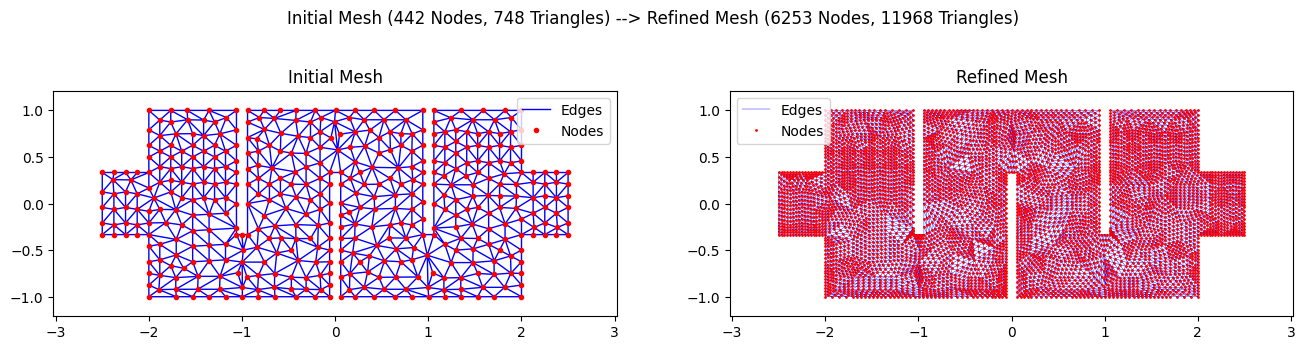

In [3]:
p_coarse, e_coarse, t_coarse = Plot_Initial_Refined_meshes(data_path='Meshes/exchanger_device_altered_mesh_data.npz', num_of_refinements=2, 
                                                           figsize=(16,4))
p_fine, e_fine, t_fine = refine(p_coarse, e_coarse, t_coarse)

In [4]:
def compute_U_P_solution(p_fine, t_fine, e_fine, p_coarse, t_coarse):

    Nv = p_fine.shape[0]
    Np = p_coarse.shape[0]
    eps = 1e-3

    xmin = p_fine[:, 0].min()
    xmax = p_fine[:, 0].max()

    inlet_idx  = np.where(np.abs(p_fine[:, 0] - xmin) < eps)[0]
    outlet_idx = np.where(np.abs(p_fine[:, 0] - xmax) < eps)[0]

    # Extract all physical boundary nodes from edge flags
    boundary_nodes = np.unique(e_fine[e_fine[:, 2] > 0, 0:2])

    # Exclude inlet and outlet from solid walls
    v_wall_idx = np.setdiff1d(boundary_nodes, np.concatenate([inlet_idx, outlet_idx]))

    lf_x = np.zeros(Nv)
    lf_y = np.zeros(Nv)
    lf_x[inlet_idx] = -1.0  

    A = calculate_velocity_A(p_fine, t_fine, kinematic_viscosity=10)
    Bx, By = calculate_pressure_B(p_fine, t_fine, p_coarse, t_coarse)
    F = calculate_F(A, Bx, By, (lf_x, lf_y))
    K = calculate_Saddle_point_K(A, Bx, By)

    dirichlet_nodes = np.unique(np.concatenate([inlet_idx, v_wall_idx]))
    K = K.tolil()

    for i in dirichlet_nodes:
        # X-velocity tracks
        K[i, :] = 0.0
        K[i, i] = 1.0
        F[i] = 0.0  

        # Y-velocity tracks (shifted by Nv)
        iy = i + Nv
        K[iy, :] = 0.0
        K[iy, iy] = 1.0
        F[iy] = 0.0  

    is_outlet_p = (np.abs(p_coarse[:, 0] - xmax) < eps)
    p_ref_idx = np.where(is_outlet_p)[0]
    p_ref = p_ref_idx[0]
    p_row = 2 * Nv + p_ref

    K[p_row, :] = 0.0
    K[p_row, p_row] = 1.0
    F[p_row] = 0.0

    print("Solving lifted system...")
    sol = spsolve(K.tocsc(), F)

    if np.any(np.isnan(sol)):
        print("Warning: NaNs detected!")

    u0_x = sol[:Nv]
    u0_y = sol[Nv:2*Nv]
    pressure = sol[2*Nv:]

    ux = u0_x + lf_x
    uy = u0_y + lf_y

    div = Bx @ ux + By @ uy
    print("||div|| =", np.linalg.norm(div))
    print("max div =", np.max(np.abs(div)))

    return ux, uy, pressure

In [5]:
ux, uy, p_sol = compute_U_P_solution(p_fine, t_fine, e_fine, p_coarse, t_coarse)

Solving lifted system...
||div|| = 0.23846420705906518
max div = 0.060763885267109324


In [7]:
np.savez_compressed(
    'Solutions/Exchanger_device.npz',
    p_fine=p_fine,
    t_fine=t_fine,
    e_fine=e_fine,
    p_coarse=p_coarse,
    t_coarse=t_coarse,
    ux=ux,
    uy=uy,
    p_sol=p_sol
)
print("Simulation data saved.")

Simulation data saved.


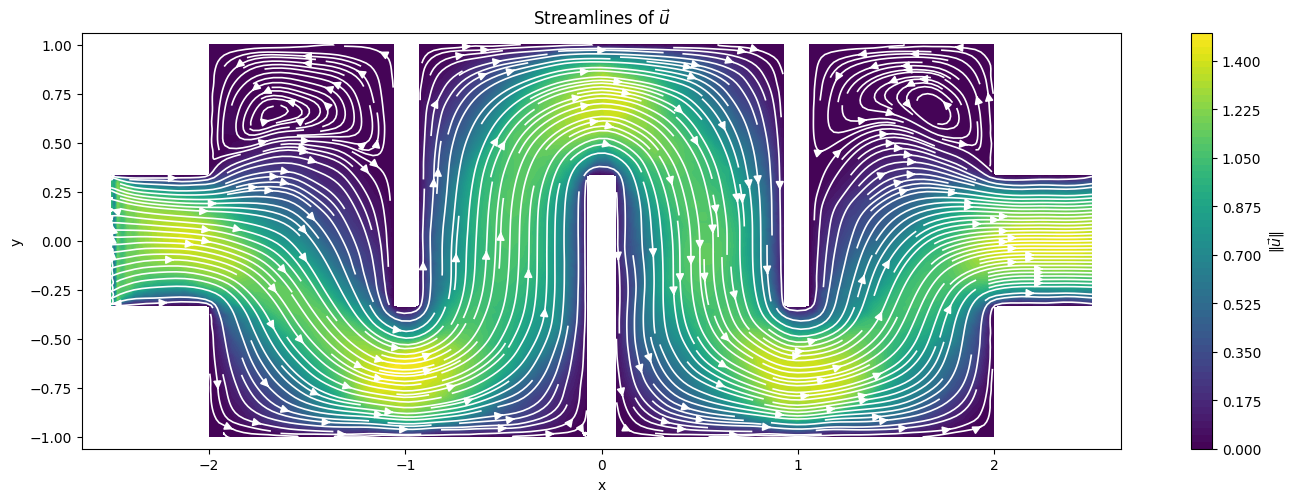

In [ ]:
plot_streamlines(p_fine, t_fine, ux, uy,
                 figsize=(15,5),
                 density=3.7)

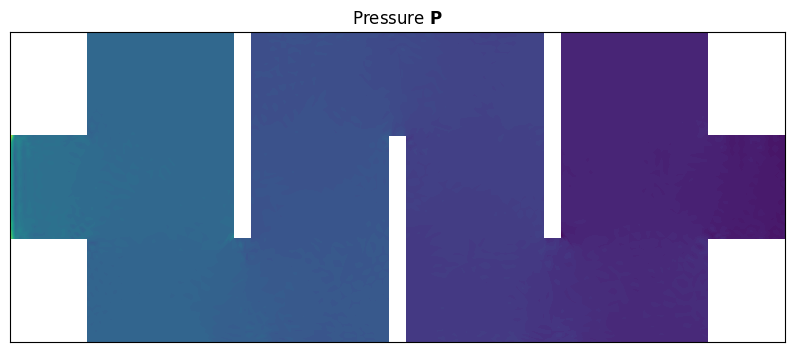

In [ ]:
data = np.load('Solutions/Winding_pipe_solution.npz')

p_fine = data['p_fine']
t_fine = data['t_fine']

p_coarse = data['p_coarse']
t_coarse = data['t_coarse']

ux = data['ux']
uy = data['uy']
p_sol = data['p_sol']

KeysView(NpzFile 'Solutions/Winding_pipe_solution.npz' with keys: p_fine, t_fine, e_fine, p_coarse, t_coarse...)